### Spatial niches: ligand-receptor pairs, gradients and biological programs

Follows `squid01_analyze_visium_HE_data.ipynb` (mouse brain, Visium H&E, `visium_hne.h5ad`).

For a central spot (or the core of a region):
1. map the k ≤ 20 nearest spots (Visium hex grid: 6 + 12 spots in rings 1-2),
2. score every ligand-receptor (LR) pair in both directions, **center → neighbors** and **neighbors → center**, against 2,000 random niches of the same tissue (z, empirical p, FDR),
3. measure ligand and receptor **gradients** along 3-6 collinear spots, from the center towards the best partner spot,
4. infer **biological programs** (50 functional programs, Reactome-summarised) from niche program activity + programs containing the significant L/R genes.

Caveat: a Visium spot is 55 µm (≈1-10 cells), so these are spot-level niches; gradients over 3-6 points are descriptive.

In [5]:
import numpy as np
import pandas as pd
import os, sys

import anndata as ad
import scanpy as sc
import squidpy as sq
from pathlib import Path

ROOT0 = Path("/home/flavio/uv/gwas/")
ROOT_SRC = ROOT0 / "src"
sys.path.append(str(ROOT_SRC))

from libs.Basic import create_dir, pdwritecsv, pdreadcsv
from libs.matplotlib_figure_style import *

import matplotlib.pyplot as plt

root0 = Path('/home/flavio/uv/squidpy/')
root_data = root0 / 'data'
root_figure = root0 / 'figures'
root_result = root0 / 'results'


root_colab = Path('/home/flavio/uv/colab')
root_reactome = root_colab / 'reactome'

# folder with niche_lr.py, programs.py, lr_mouseconsensus.csv
ROOT_SRC = root0 / 'src' 
sys.path.append(str(ROOT_SRC))

import programs.niche_lr as nl
import programs.programs as pg

In [2]:
filename_vis = root_data / "visium_hne.h5ad"
adata = ad.read_h5ad(filename_vis)
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'features_cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'features_cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'liana_res', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'features', 'features_summary_scale1.0', 'features_summary_scale2.0', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 

### Expression layer

The niche scores need **log-normalised, non-negative** values. In this object `adata.X` is log-normalised and `.raw` holds counts, so `layer=None` (use `X`).

In [3]:
X = adata.X
print(type(X), X.shape, "min", X.min(), "max", X.max())

coords = adata.obsm["spatial"]
spacing = nl.spot_spacing(coords)          # ~137 px centre-to-centre
um_per_px = 100 / spacing                  # Visium: 100 um centre-to-centre
print(f"spot spacing = {spacing:.1f} px  ->  {um_per_px:.3f} um/px")

<class 'scipy.sparse._csr.csr_matrix'> (2688, 18078) min 0.0 max 8.859275
spot spacing = 137.0 px  ->  0.730 um/px


### Programs (human catalogue -> mouse symbols)

`to_mouse` capitalises human symbols and applies explicit orthologs (HLA -> H2, FCGR3A -> Fcgr4, ...); genes absent from the data are dropped and poorly covered programs are reported.

In [4]:
programs_m = pg.to_mouse(pg.PROGRAMS, adata.var_names)
states_m   = pg.to_mouse(pg.CELL_STATES, adata.var_names)

df_prog = pd.DataFrame([(c, p, len(g)) for c, d in programs_m.items() for p, g in d.items()],
                       columns=["category", "program", "n_genes_in_data"])
print(df_prog.shape)
df_prog.sort_values("n_genes_in_data").head(10)

programs with <50% genes found in data:
        category    program  n_human  n_mouse  n_in_data
epithelial_PDAC  classical        7        6          2
epithelial_PDAC basal_like        7        7          2
(51, 3)


,category,program,n_genes_in_data
1,cell_death,apoptosis_extrinsic,10
3,cell_death,pyroptosis_inflammasome,11
19,metabolism,iron_metabolism,11
2,cell_death,necroptosis,12
46,immune,T_cell_exhaustion_checkpoint,12
47,immune,humoral_B_cell,12
34,signaling,Hedgehog_signaling,12
11,stress,senescence_SASP,13
41,immune,complement,13
5,cell_death,necrosis_DAMP,13


### Reactome: every pathway -> program (or background class)

`reactome_pathways.tsv` has names only (no genes), so this is the name-based summary of all Reactome pathways into the 50 programs.
Pathways that are disease variants, pathogens or drugs are *excluded*; housekeeping biology goes to *context* classes (transcription, translation, transport, GPCR, ...).
With `ReactomePathways.gmt` (gene members) use `pg.expand_with_reactome(pg.load_gmt(path))` to build the complete gene sets.

In [7]:
filename_reac = root_reactome / "reactome_pathways.tsv"

df_reac = pg.load_reactome_tsv(filename_reac, species="Mus musculus")
df_cls  = pg.classify_reactome(df_reac)
df_sum  = pg.summarize_reactome(df_cls)

print(df_cls.drop_duplicates("pathway").level.value_counts())

fname = "reactome_mouse_pathway_to_program.tsv"
if not (root_result / fname).exists():
    pdwritecsv(df_cls, fname, root_result, verbose=True)

df_sum[df_sum.level == "program"].head(6)

level
program         1388
context          384
exclude           45
unclassified       5
Name: count, dtype: int64
Table saved ((2074, 6)) at '/home/flavio/uv/squidpy/results/reactome_mouse_pathway_to_program.tsv'


,level,category,label,n_pathways
11,program,signaling,RTK_MAPK,198
12,program,metabolism,fatty_acid_lipid,135
13,program,neural,synaptic_neurotransmission,108
14,program,stress,DNA_damage_response,91
15,program,proliferation,G2_M_mitosis,78
16,program,immune,inflammation_TNF_NFkB,74


### Choose the center

Options: `barcode=...`, `xy=(x, y)`, `mask=<bool array or obs column>`, `program="synaptic_neurotransmission"` (hotspot), or one center per anatomical cluster (`centers_by_group`: the most interior spot of each cluster).

In [8]:
centers = nl.centers_by_group(adata, "cluster")
centers

{'Cortex_2': 2135,
 'Cortex_5': 127,
 'Thalamus_2': 2400,
 'Hypothalamus_2': 1828,
 'Cortex_4': 700,
 'Fiber_tract': 1491,
 'Lateral_ventricle': 1982,
 'Cortex_1': 1367,
 'Hypothalamus_1': 1284,
 'Striatum': 2041,
 'Hippocampus': 2583,
 'Pyramidal_layer': 1936,
 'Thalamus_1': 1631,
 'Cortex_3': 2600,
 'Pyramidal_layer_dentate_gyrus': 2588}

In [10]:
cluster_name = "Hippocampus"
center = centers[cluster_name]

# alternatives:
# center = nl.select_center(adata, program="synaptic_neurotransmission", programs=programs_m)
# center = nl.select_center(adata, barcode="AAACAAGTATCTCCCA-1")

lr_m = nl.load_lr("mouseconsensus")
print(lr_m.shape, adata.obs_names[center], adata.obs.loc[adata.obs_names[center], "cluster"])

(3989, 2) TTCCTCGAGGGTGTCT-1 Hippocampus


### Run the niche analysis

In [11]:
# background: whole tissue (None) -> "what is special about this niche";
#             other clusters        -> "this region vs the rest"
bg_mask = (adata.obs["cluster"] != cluster_name).values
# bg_mask = None

res = nl.analyze_niche(
    adata, center, k=20,
    center_pool=6,         # center + ring 1 pooled into a central region (damps single-spot noise);
                           # partners = the remaining 14 spots (ring 2 + 2 of ring 3). 0 = single spot
    lr=lr_m, programs=programs_m,
    bg_mask=bg_mask,
    layer=None,            # adata.X is log-normalised
    fdr=0.1,
    n_top_gradients=15,
    n_line_cells=6,        # 3-6 collinear spots
    um_per_unit=um_per_px, # gradients per um
    n_background=2000,
)
res.neighbors.head(8)

,idx,barcode,dx,dy,dist,ring,angle_deg
0,1346,CTTGTACTTGTTGACT-1,137,0,137.000000,1,0.000000
1,855,CCAAACAGAACCCTCG-1,-69,119,137.557261,1,120.106527
2,1380,GAACACACATCAACCA-1,69,119,137.557261,1,59.893473
3,1636,GCTAATACCGAATGCC-1,-138,0,138.000000,1,180.000000
4,683,CAACGACCCGTTTACA-1,69,-120,138.423264,1,299.898902
5,2564,TTCAACGACCCGACCG-1,-69,-120,138.423264,1,240.101098
6,383,AGCATCGTCGATAATT-1,206,119,237.901240,2,30.013733
7,2325,TCTCTAATAGCTGGTA-1,206,-120,238.403020,2,329.778162


### Neighbours: cluster composition

In [12]:
nb = res.neighbors.copy()
nb["cluster"] = adata.obs["cluster"].values[nb.idx]
nb.groupby(["ring", "cluster"], observed=True).size().unstack(fill_value=0)

cluster,Hippocampus
ring,
1,6
2,12
3,2


### Top LR pairs (both directions)

`center->neighbors`: ligand in the center, receptor in the neighbours. `neighbors->center`: the reverse.
`z` = niche score vs. random niches. `fdr` uses the empirical p, switching to the Gaussian tail of z when fewer than 5 background niches reach the observed score (the empirical p has a floor of 1/(n_background+1)); `fdr_emp` is the purely empirical version.

In [13]:
cols = ["ligand", "receptor", "direction", "score", "z", "fdr", "fdr_emp",
        "ligand_sender", "receptor_receiver", "ligand_programs", "receptor_programs"]

df_lr = res.lr

fname = f"niche_lr_{cluster_name}.tsv"
if not (root_result / fname).exists():
    pdwritecsv(df_lr, fname, root_result, verbose=True)

df_lr[cols].head(25)

Table saved ((1149, 16)) at '/home/flavio/uv/squidpy/results/niche_lr_Hippocampus.tsv'


,ligand,receptor,direction,score,z,fdr,fdr_emp,ligand_sender,receptor_receiver,ligand_programs,receptor_programs
0,Saa1,Scarb1,center->neighbors,0.169925,9.506204,5.745000e-10,0.287106,0.202318,0.310002,,
1,Dkk2,Lrp6,center->neighbors,0.186314,7.785519,5.745000e-10,0.459370,0.144136,0.477629,,WNT_signaling
2,Hapln1,Igdcc4,neighbors->center,0.442641,6.490509,1.638222e-08,0.287106,0.447838,0.947981,,
3,Cd38,Pecam1,center->neighbors,0.408994,5.251167,2.170722e-05,0.287106,0.460920,0.534249,,angiogenesis
4,Hsp90b1,Tlr7,neighbors->center,0.745380,3.682957,2.648950e-02,0.287106,1.709782,0.325255,,
5,Icam4,Itga2b,center->neighbors,0.110660,4.974028,5.024363e-01,0.502436,0.117525,0.241689,,
6,Mmp9,Itgam,center->neighbors,0.146177,4.692948,5.024363e-01,0.502436,0.331183,0.319269,ECM_remodeling_fibrosis,complement
7,Mmp2,Pecam1,center->neighbors,0.204602,4.519632,5.024363e-01,0.502436,0.115349,0.534249,"ECM_remodeling_fibrosis, EMT",angiogenesis
8,Mmp9,Reck,center->neighbors,0.111895,5.346647,5.742129e-01,0.574213,0.331183,0.131109,ECM_remodeling_fibrosis,
9,Hapln1,Igdcc4,center->neighbors,0.333670,3.397418,5.742129e-01,0.574213,0.455908,0.404648,,


### Inferred biological functions

`z` = niche program activity vs. random niches; `lr_support` = Σ -log10(p) of significant LRs whose L or R is in the program; `score` combines both ranks.

In [14]:
df_fun = res.functions

fname = f"niche_functions_{cluster_name}.tsv"
if not (root_result / fname).exists():
    pdwritecsv(df_fun, fname, root_result, verbose=True)

df_fun[["category", "program", "z", "percentile", "lr_support", "n_lr", "top_lr", "score"]].head(15)

Table saved ((51, 11)) at '/home/flavio/uv/squidpy/results/niche_functions_Hippocampus.tsv'


,category,program,z,percentile,lr_support,n_lr,top_lr,score
0,tissue_remodeling,angiogenesis,-0.369971,40.45,7.121656,1,Cd38->Pecam1 (C>N),0.852941
1,cell_death,apoptosis_extrinsic,0.946745,86.70,0.000000,0,,0.745098
2,immune,immunosuppression,0.922108,88.55,0.000000,0,,0.735294
3,immune,complement,0.880962,84.95,0.000000,0,,0.725490
4,signaling,TGFb_signaling,0.848744,83.30,0.000000,0,,0.715686
5,immune,humoral_B_cell,0.202955,66.90,0.000000,0,,0.705882
6,signaling,WNT_signaling,-1.274913,3.15,12.000000,1,Dkk2->Lrp6 (C>N),0.705882
7,metabolism,iron_metabolism,0.201076,68.80,0.000000,0,,0.696078
8,immune,cytotoxic_T_NK,0.128947,67.25,0.000000,0,,0.686275
9,immune,antigen_presentation_MHCI,0.075464,63.05,0.000000,0,,0.676471


### Cell states in the niche (identity markers, activity only)

In [15]:
df_states = nl.niche_program_activity(adata, center, res.neighbors, states_m, n_background=2000, bg_mask=bg_mask)
df_states.head(10)

,category,program,n_genes,niche_score,center_score,z,percentile
0,brain,microglia,6,0.444059,1.481958,2.175772,97.60
1,macrophage,TAM,7,0.414867,0.952359,2.146707,95.80
2,brain,astrocyte,6,0.483666,1.002691,1.586831,91.40
3,brain,DAM_microglia,7,0.158457,0.604630,1.086277,86.05
4,brain,reactive_astrocyte,6,0.271265,0.902861,0.975492,85.55
5,brain,excitatory_neuron,5,0.352730,0.333941,0.584075,59.70
6,fibroblast,myCAF,6,0.105033,-0.054826,0.534563,81.10
7,humoral,plasma,5,0.053355,-0.066898,0.445454,71.60
8,endothelial,activated,3,0.033056,-0.573176,0.137957,61.75
9,humoral,TLS,4,0.015431,-0.082901,0.105859,74.00


### Gradients along collinear spots

A slope counts as a trend only if |Spearman ρ| ≥ 0.6 (`pattern`: source→sink, co-decreasing, ligand/receptor gradient only, flat).
`consistent_with_direction`: center→neighbors → ligand highest at the center and decreasing, receptor expressed downstream; neighbors→center → receptor highest at the center, ligand rising towards the sender.

In [16]:
df_grad = res.gradients
df_grad[["key", "n_cells", "L_slope", "L_rho", "R_slope", "R_rho", "LR_corr",
         "pattern", "consistent_with_direction", "z", "fdr"]]

,key,n_cells,L_slope,L_rho,R_slope,R_rho,LR_corr,pattern,consistent_with_direction,z,fdr
0,Saa1->Scarb1|center->neighbors,6,-0.001162,-0.654654,0.000548,0.318874,-0.459697,ligand gradient only,True,9.506204,5.745000e-10
1,Dkk2->Lrp6|center->neighbors,6,0.000000,0.000000,-0.000665,-0.600000,NaN,receptor gradient only,False,7.785519,5.745000e-10
2,Hapln1->Igdcc4|neighbors->center,6,-0.001485,-0.777542,-0.001875,-0.777542,0.971092,co-decreasing,False,6.490509,1.638222e-08
3,Cd38->Pecam1|center->neighbors,6,-0.001162,-0.654654,-0.000601,-0.392792,-0.200000,ligand gradient only,True,5.251167,2.170722e-05
4,Hsp90b1->Tlr7|neighbors->center,6,-0.001303,-0.394665,0.000000,0.000000,NaN,flat,False,3.682957,2.648950e-02


Plot saved: /home/flavio/uv/squidpy/figures/niche_map_Hippocampus.png


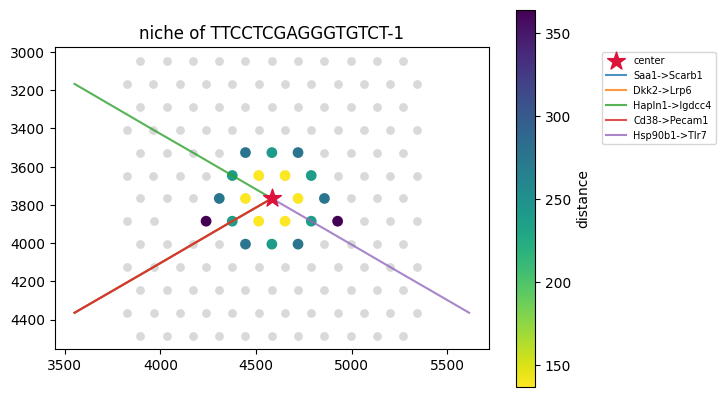

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
nl.plot_niche(adata, res, ax=ax)

filename = root_figure / f"niche_map_{cluster_name}.png"
if not filename.exists():
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Plot saved: {filename}")
plt.show()

Plot saved: /home/flavio/uv/squidpy/figures/niche_gradients_Hippocampus.png


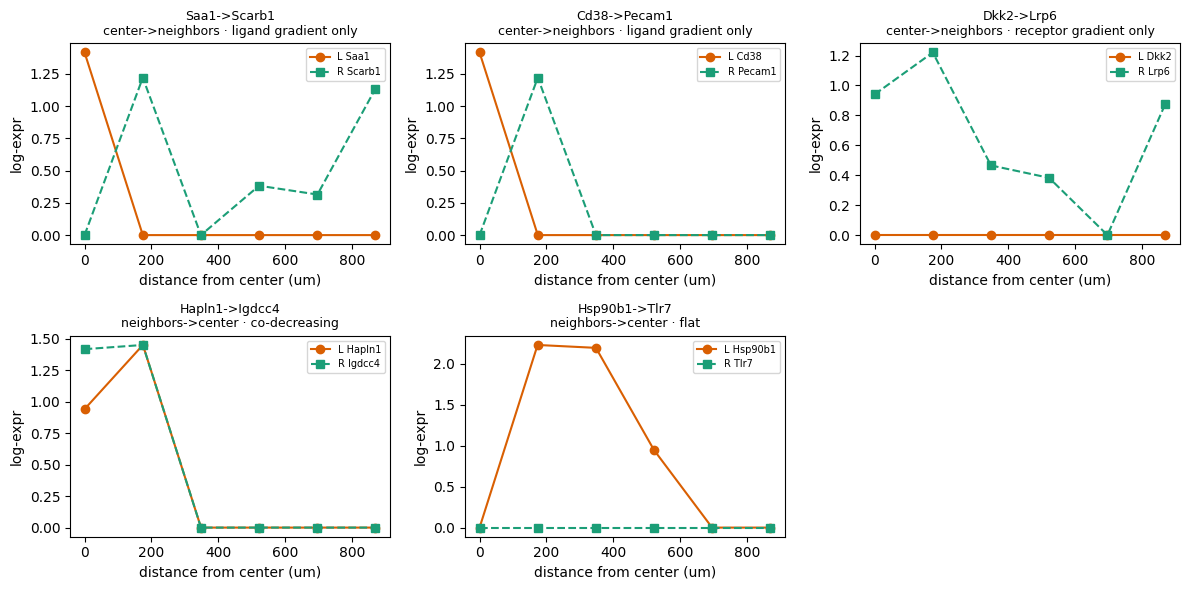

In [18]:
keys = df_grad.sort_values(["consistent_with_direction", "z"], ascending=False).key.head(6).tolist()
fig = nl.plot_gradients(res, keys)

filename = root_figure / f"niche_gradients_{cluster_name}.png"
if not filename.exists():
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Plot saved: {filename}")
plt.show()

### Cross-check with LIANA+ bivariate (from squid01)

Local cosine score of the same LR at the center and its neighbours, and global rank by Moran's R.

In [19]:
filename_lr = root_data / "visium_hne_liana_bivariate.h5ad"
if filename_lr.exists():
    lrdata = ad.read_h5ad(filename_lr)
    df_chk = nl.liana_local_check(lrdata, res, n=25)
    display(df_chk)

,lr,direction,niche_z,liana_local_center,liana_local_neighbors,liana_global_rank
0,Saa1^Scarb1,center->neighbors,9.506204,NaN,NaN,NaN
1,Dkk2^Lrp6,center->neighbors,7.785519,NaN,NaN,NaN
2,Hapln1^Igdcc4,neighbors->center,6.490509,NaN,NaN,NaN
3,Cd38^Pecam1,center->neighbors,5.251167,NaN,NaN,NaN
4,Hsp90b1^Tlr7,neighbors->center,3.682957,NaN,NaN,NaN
5,Icam4^Itga2b,center->neighbors,4.974028,NaN,NaN,NaN
6,Mmp9^Itgam,center->neighbors,4.692948,NaN,NaN,NaN
7,Mmp2^Pecam1,center->neighbors,4.519632,NaN,NaN,NaN
8,Mmp9^Reck,center->neighbors,5.346647,NaN,NaN,NaN
9,Hapln1^Igdcc4,center->neighbors,3.397418,NaN,NaN,NaN


### All clusters: program x niche matrix

In [20]:
fname = "niche_functions_by_cluster.tsv"
force = False

if (root_result / fname).exists() and not force:
    df_mat = pdreadcsv(fname, root_result).set_index("program")
else:
    df_mat, results = nl.scan_niches(adata, centers, value="z", exclude_own_group="cluster",
                                     center_pool=6, lr=lr_m, programs=programs_m,
                                     um_per_unit=um_per_px, n_background=1000, n_top_gradients=10)
    pdwritecsv(df_mat.reset_index(), fname, root_result, verbose=True)

df_mat.round(1).head()

Table saved ((51, 16)) at '/home/flavio/uv/squidpy/results/niche_functions_by_cluster.tsv'


,Cortex_2,Cortex_5,Thalamus_2,Hypothalamus_2,Cortex_4,Fiber_tract,Lateral_ventricle,Cortex_1,Hypothalamus_1,Striatum,Hippocampus,Pyramidal_layer,Thalamus_1,Cortex_3,Pyramidal_layer_dentate_gyrus
program,,,,,,,,,,,,,,,
DNA_damage_response,-0.5,-2.3,-0.2,-1.4,1.9,-0.3,1.5,1.9,-0.1,0.5,-2.2,-1.3,1.5,1.8,1.1
ECM_integrin_adhesion,-0.4,0.9,-1.2,0.1,-0.0,2.8,2.3,-0.4,-0.6,0.5,-1.1,-1.3,-0.8,-0.9,-0.9
ECM_remodeling_fibrosis,-1.1,-0.3,0.9,0.6,-1.1,0.0,3.9,-0.9,0.1,0.7,-0.4,-0.7,1.0,0.1,-0.9
EMT,-1.1,-0.6,-0.2,0.2,-0.8,0.0,3.0,-0.9,-0.6,1.2,-0.6,0.3,-0.2,-0.0,-0.8
ER_stress_UPR,-0.7,-2.4,-0.0,0.2,1.6,-0.8,2.3,0.8,1.1,1.4,-3.9,-1.3,-1.0,0.9,0.4


Plot saved: /home/flavio/uv/squidpy/figures/niche_programs_by_cluster.png


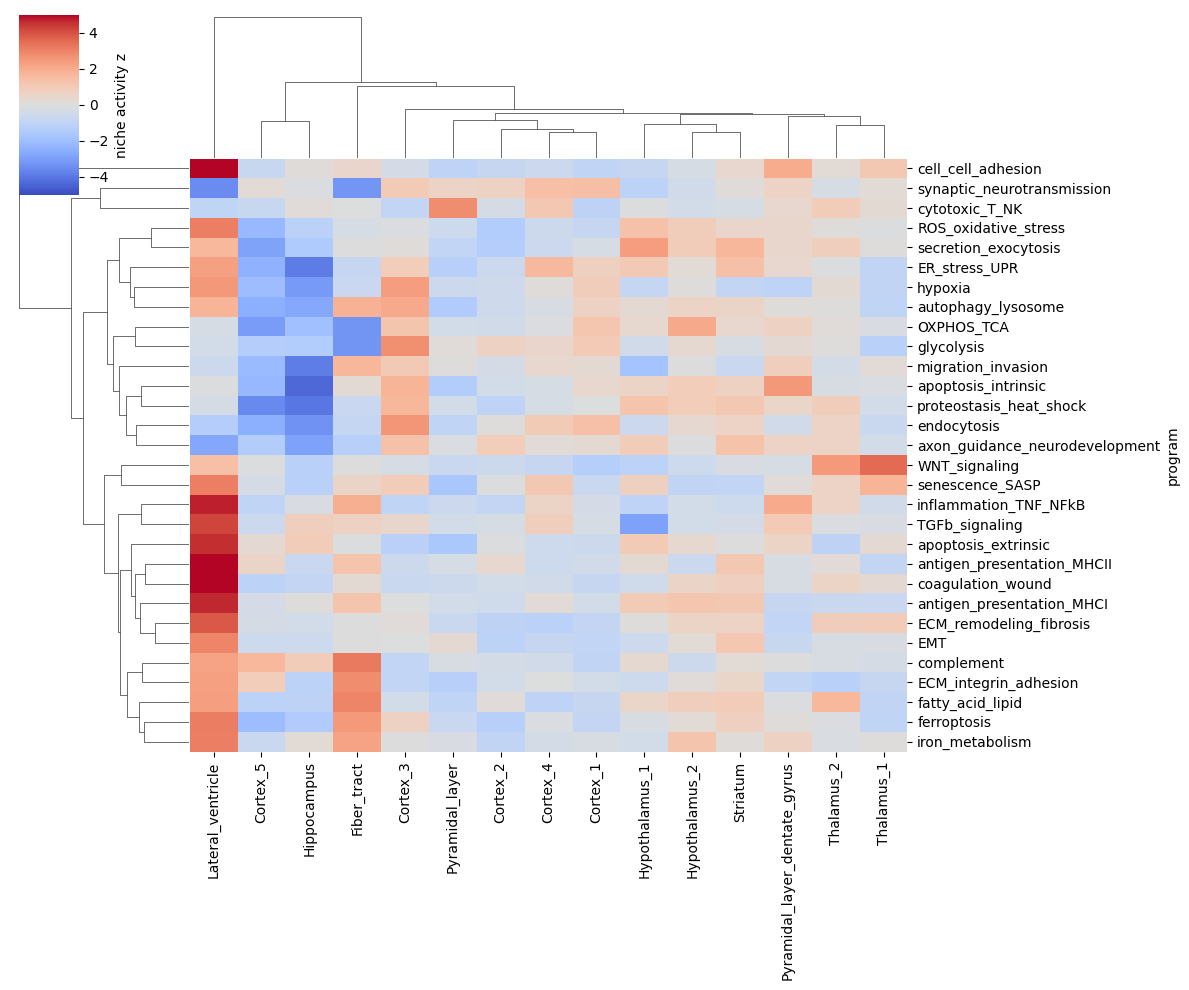

In [21]:
import seaborn as sns

top = df_mat.loc[df_mat.abs().max(1).sort_values(ascending=False).index[:30]]
g = sns.clustermap(top, cmap="coolwarm", center=0, figsize=(12, 10), vmin=-5, vmax=5,
                   cbar_kws={"label": "niche activity z"})

filename = root_figure / "niche_programs_by_cluster.png"
if not filename.exists():
    g.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Plot saved: {filename}")
plt.show()